MAE : 156.49
RMSE: 671.34
R²  : 0.326


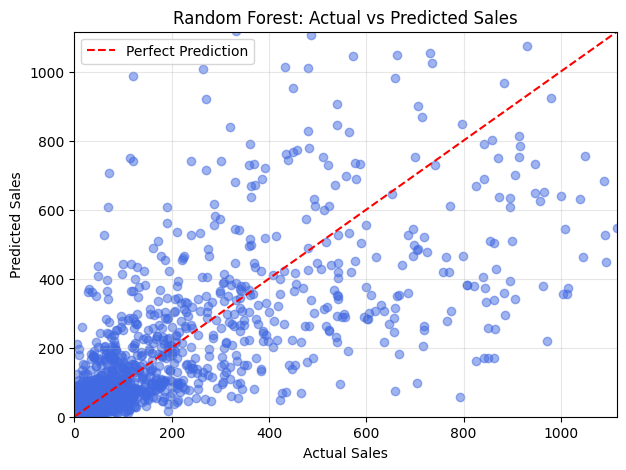

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("/content/exp_2_train.csv")

df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Ship Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

features = ["Ship Mode", "Segment", "Region", "State", "City",
    "Category", "Sub-Category", "Product Name",
    "Year", "Month", "Ship Days"]

X = df[features]
y = df["Sales"]

categorical = ["Ship Mode", "Segment", "Region", "State", "City",
    "Category", "Sub-Category", "Product Name"]

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical)
], remainder="passthrough")

X = preprocessor.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100,
    random_state=42,
    n_jobs=-1)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 3))

limit = y_test.quantile(0.95)
plt.figure(figsize=(7, 5))
plt.scatter(y_test[y_test <= limit],
    y_pred[y_test <= limit],
    color="royalblue",
    alpha=0.5)

plt.plot([0, limit], [0, limit],
    color="red",
    linestyle="--",
    label="Perfect Prediction")

plt.xlim(0, limit)
plt.ylim(0, limit)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Random Forest: Actual vs Predicted Sales")
plt.legend()
plt.grid(alpha=0.3)
plt.show()